In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
yelp_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/train.csv")
yelp_val_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/dev.csv")
yelp_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/test.csv")

dynabench_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/train.csv")
dynabench_val_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/dev.csv")
dynabench_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/test.csv")

yelp_dynabench_2500_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/train.csv")
yelp_dynabench_2500_val_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/dev.csv")
yelp_dynabench_2500_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/test.csv")

In [3]:
dataFrames = [[yelp_train_df, yelp_val_df, yelp_test_df], [dynabench_train_df, dynabench_val_df, dynabench_test_df], [yelp_dynabench_2500_train_df, yelp_dynabench_2500_val_df, yelp_dynabench_2500_test_df]]

# Mapping function
label_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}

# Iterate over each DataFrame name
for df_train, df_val, df_test in dataFrames:
    
    # Apply the mapping to the 'label' column
    df_train['label'] = df_train['label'].map(label_mapping)
    df_val['label'] = df_val['label'].map(label_mapping)
    df_test['label'] = df_test['label'].map(label_mapping)  

# Example to check the changes
print(yelp_train_df.head())

                                                text  label
0  I haven't been on an AA flight that hasn't bee...      0
1  Went differently because of his reviews and pr...      1
2         So if you see this dog, AVOID AVOID AVOID!      0
3                 De-li-cious tacos for $9 straight.      2
4          He them saw me, and asked what was wrong.      1


In [4]:

def preprocess_with_lemmatization(data):
    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Define stop words
    stop_words = set(stopwords.words('english'))
    
    # Preprocessing function
    def preprocess_text(text):
        # Remove non-alphabetic characters
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        # Convert to lowercase
        text = text.lower()
        # Tokenize
        words = word_tokenize(text)
        # Remove stop words and apply lemmatization
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return ' '.join(words)
    
    # Apply preprocessing to each row in the dataframe
    data['text'] = data['text'].apply(preprocess_text)
    
    return data


In [5]:
for df_train, df_val, df_test in dataFrames:
    # Apply the preprocessing function
    df_train = preprocess_with_lemmatization(df_train)
    df_val = preprocess_with_lemmatization(df_val)    
    df_test = preprocess_with_lemmatization(df_test)

# Example to check the changes
print(yelp_train_df.head())

                                               text  label
0           havent aa flight hasnt delayed canceled      0
1  went differently review proximity ann centennial      1
2                         see dog avoid avoid avoid      0
3                           delicious taco straight      2
4                                   saw asked wrong      1


In [6]:
# Function to prepare the data
def prepare_data(train_df, val_df, test_df):
    vectorizer = TfidfVectorizer()
    X_train = vectorizer.fit_transform(train_df['text']).toarray()
    y_train = train_df['label'].values
    X_val = vectorizer.transform(val_df['text']).toarray()
    y_val = val_df['label'].values
    X_test = vectorizer.transform(test_df['text']).toarray()
    y_test = test_df['label'].values
    return X_train, y_train, X_val, y_val, X_test, y_test

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 3)  # 3 classes: 0 (negative), 1 (neutral), 2 (positive)

    def forward(self, x):
        return self.linear(x)

# Function to train the model
def train_model(X_train, y_train, X_val, y_val, input_dim):
    model = LogisticRegressionModel(input_dim)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    history = {'train_loss': [], 'val_loss': []}
    
    model.train()
    for epoch in range(100):  # Number of epochs
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}, Train Loss: {train_loss}, Validation Loss: {val_loss}')
        
        model.train()
    
    return model, history

# Function to predict the labels
def predict_model(model, X_test):
    model.eval()
    with torch.no_grad():
        outputs = model(torch.tensor(X_test, dtype=torch.float32))
        _, predicted = torch.max(outputs, 1)
    return predicted.numpy()

# Assuming dataFrames contains triplets of training, validation, and testing dataframes
# Example: dataFrames = [(train_df1, val_df1, test_df1), (train_df2, val_df2, test_df2), (train_df3, val_df3, test_df3)]
prediction = []
histories = []

# Apply the function to each set of dataframes
for df_train, df_val, df_test in dataFrames:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_data(df_train, df_val, df_test)
    input_dim = X_train.shape[1]
    model, history = train_model(X_train, y_train, X_val, y_val, input_dim)
    y_pred = predict_model(model, X_test)
    prediction.append((y_test, y_pred))
    histories.append(history)

Epoch 1, Train Loss: 1.0635508617974052, Validation Loss: 1.0168650857115213
Epoch 2, Train Loss: 0.9908935870507825, Validation Loss: 0.961484800925297
Epoch 3, Train Loss: 0.9360334377778347, Validation Loss: 0.922938528314101
Epoch 4, Train Loss: 0.893738475997185, Validation Loss: 0.8955049446198793
Epoch 5, Train Loss: 0.8598555693608273, Validation Loss: 0.8757162109940453
Epoch 6, Train Loss: 0.831731904550197, Validation Loss: 0.8603709709327833
Epoch 7, Train Loss: 0.8079576114284674, Validation Loss: 0.8490464418335298
Epoch 8, Train Loss: 0.7873890511436608, Validation Loss: 0.8401450187759062
Epoch 9, Train Loss: 0.7692938718052418, Validation Loss: 0.8335433734201751
Epoch 10, Train Loss: 0.7531272391402676, Validation Loss: 0.8284501354251288
Epoch 11, Train Loss: 0.7384936191736519, Validation Loss: 0.8244055947371288
Epoch 12, Train Loss: 0.7251715560149784, Validation Loss: 0.821340576737328
Epoch 13, Train Loss: 0.7130809548463205, Validation Loss: 0.819193620069892
E

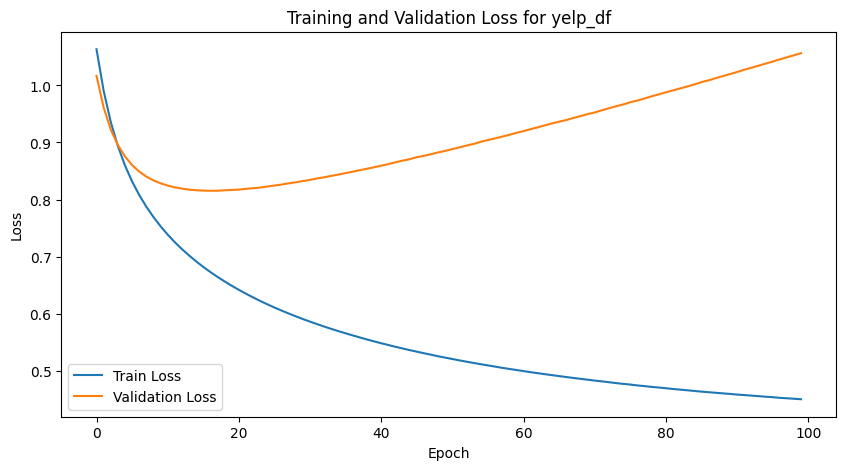

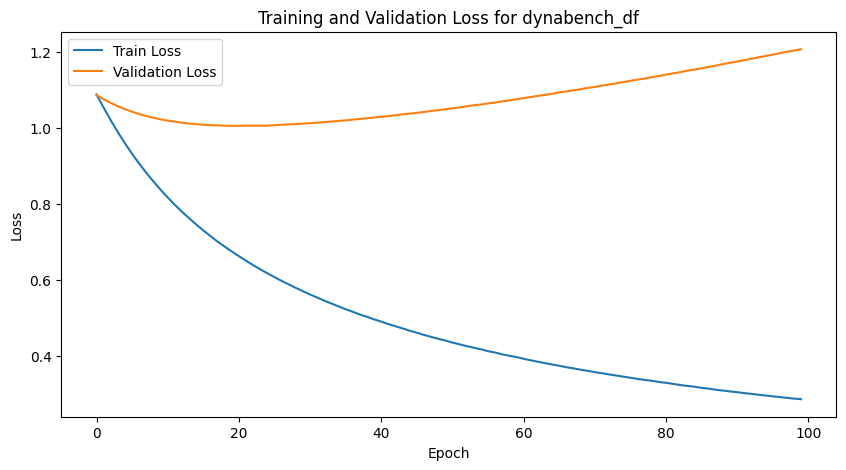

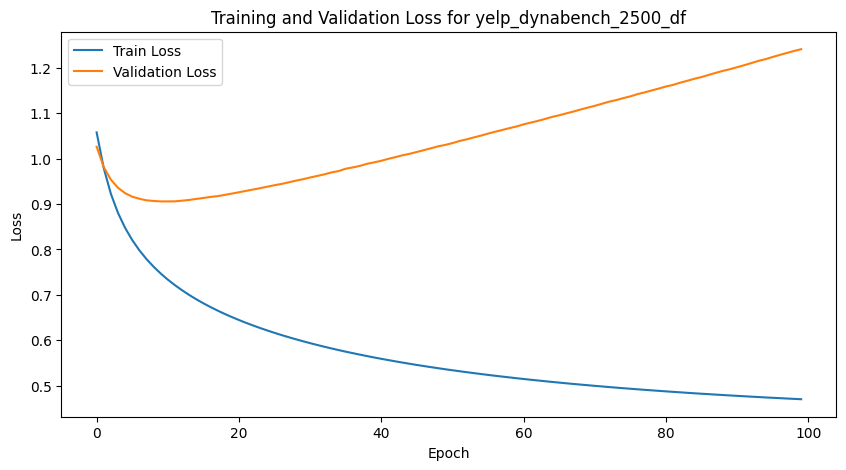

In [7]:
# Evaluate each prediction
dataset_names = ['yelp_df', 'dynabench_df', 'yelp_dynabench_2500_df']
# Plot training and validation loss
for i, (history, dataset_name) in enumerate(zip(histories, dataset_names)):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'Training and Validation Loss for {dataset_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

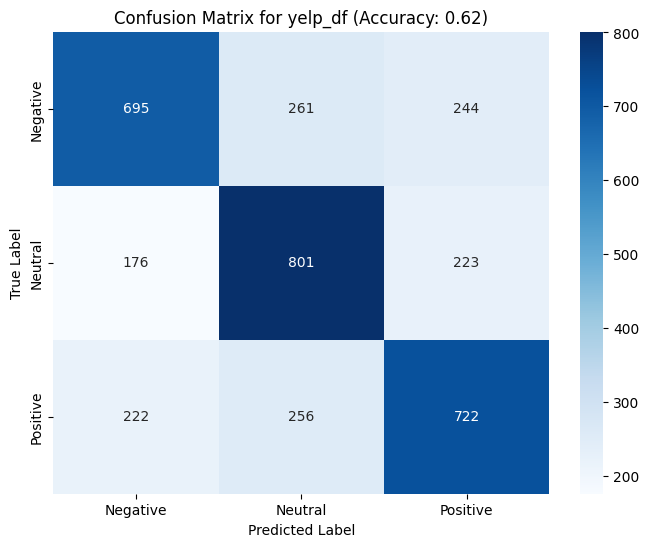

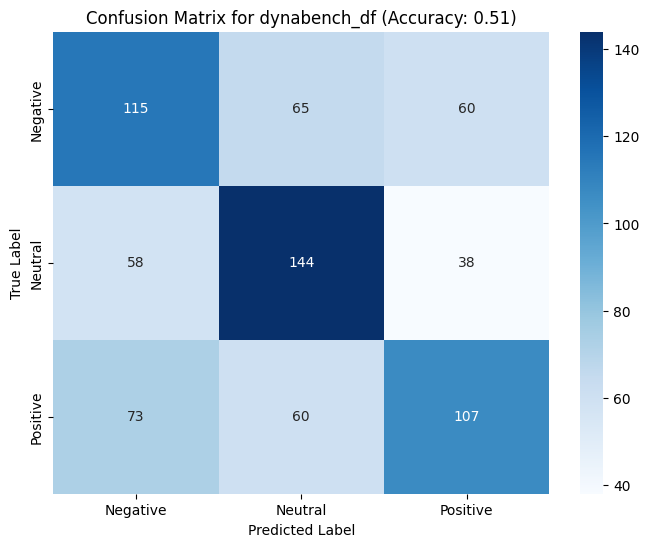

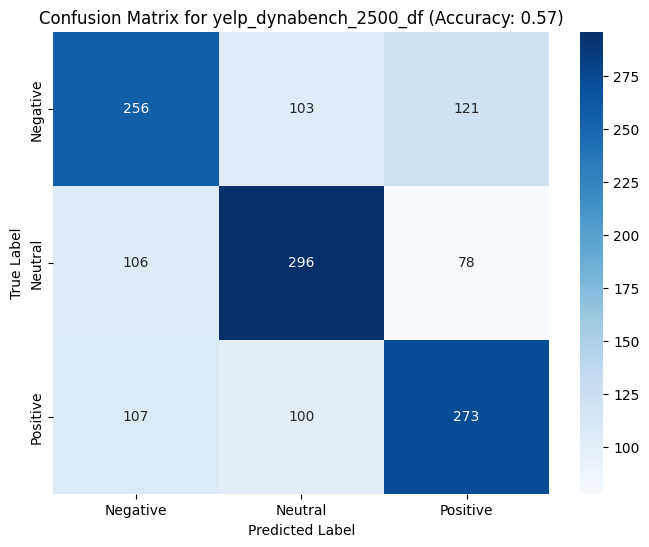

In [8]:
# Function to calculate accuracy and plot confusion matrix
def evaluate_sentiment(df_y_test, df_y_pred, df_name):
    accuracy = accuracy_score(df_y_test, df_y_pred)
    conf_matrix = confusion_matrix(df_y_test, df_y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {df_name} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Evaluate each prediction
for df_name, (df_y_test, df_y_pred) in zip(dataset_names, prediction):
    evaluate_sentiment(df_y_test, df_y_pred, df_name)